# H6: Latent vs. Observed World — разрыв между миром и его отражением

## Гипотеза

При работе замкнутого цикла рекомендаций **наблюдаемые логи** перестают отражать 
**истинные предпочтения** пользователей: модель обучается на собственной политике, 
а не на структуре реального мира.

Формально: метрика **exposure dependence** — доля дисперсии обратной связи, 
объясняемая прошлыми экспозициями, а не истинной ценностью объекта, — 
монотонно растёт со временем:
$$\frac{d}{dt}\,\beta_2(t) > 0$$
где $\beta_2(t)$ — коэффициент при `past_exposure` в регрессии:
$$\text{observed\_feedback} = \beta_0 + \beta_1 \cdot \text{true\_utility} + \beta_2 \cdot \text{past\_exposure} + \varepsilon$$

## Ключевые понятия

### Latent world (скрытый мир)
Истинные предпочтения пользователей: $p_{ij}^{\text{true}} = \sigma(u_i \cdot v_j)$. 
Эти предпочтения **не наблюдаются** системой напрямую. Система видит только клики.

### Observed world (наблюдаемый мир)
То, что фиксируется в логах: клики под влиянием рекомендаций. 
При α > 0: $P(\text{клик}) = \alpha \cdot \hat{p}_{ij} + (1-\alpha) \cdot p_{ij}^{\text{true}}$. 
Чем больше α, тем сильнее клики отражают рекомендации, а не вкусы.

### Exposure dependence (зависимость от экспозиции)
Доля вариации наблюдаемых кликов, объясняемая **историей показов**, а не качеством объекта. 
Рост этой метрики означает, что модель «учится рекомендовать то, что уже рекомендовала» — 
самоусиливающийся цикл без обратной связи от реального мира.

## Значение для доверия к метрикам

Результат H6: наблюдаемые оффлайн-метрики (CTR, NDCG) могут расти, 
даже если истинное качество (по скрытым предпочтениям) падает. 
**Вывод для практики**: нельзя доверять только A/B-метрикам на собственных данных.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

from sim.environment import SimulationEnvironment, ExperimentDataset
from sim.user_generator import GMMUserGenerator
from sim.click_model import ClickModel
from sim.metrics import ndcg_at_k
from models.rec_models import RecModel
from models.serving import ServingPolicy

matplotlib.rcParams['figure.dpi'] = 120
FIGURES_DIR = Path('../paper/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EMB_DIM = 4; N_USERS = 120; N_ITEMS = 60; K = 5; T = 80; PERIOD = 5
np.random.seed(42); torch.manual_seed(42)
items_emb = np.random.randn(N_ITEMS, EMB_DIM)
means = [np.array([2.,0.,1.,0.5]), np.array([-2.,1.,-1.,0.5]), np.array([0.,-2.,0.5,-1.5])]
covs = [0.5*np.eye(EMB_DIM)]*3
weights = np.array([0.4, 0.35, 0.25])
print('Setup done')

Setup done


## Конфигурация эксперимента

| Параметр | Значение | Смысл |
|----------|---------|-------|
| `EMB_DIM` | 4 | Размерность эмбеддингов (4D для скорости, но все закономерности сохраняются) |
| `N_USERS` | 120 | Размер аудитории |
| `N_ITEMS` | 60 | Размер каталога |
| `K` | 5 | Размер рекомендательного списка |
| `T` | 80 | Длина симуляции |
| `PERIOD` | 5 | Частота переобучения |

### Допущения

1. **Истинные предпочтения статичны**: $p_{ij}^{\text{true}}$ вычислены однажды из начальных эмбеддингов 
 и не меняются — это позволяет явно измерить отклонение наблюдаемого от истинного.

2. **Adherence α = 0.7**: достаточно высокий, чтобы создать заметный feedback loop 
 за 80 шагов.

3. **Среда `H6Environment`**: расширяет `SimulationEnvironment` дополнительным 
 логированием `(t, true_utility, past_exposure, observed_rating)` для каждого взаимодействия.

In [2]:
# Расширенная среда с логированием детальных данных для H6
class H6Environment(SimulationEnvironment):
 def __init__(self, *args, **kwargs):
 super().__init__(*args, **kwargs)
 self.detailed_logs = [] # (t, true_utility, past_exposure, observed_rating)

 def step(self, t):
 dataset = self.dataset
 U = dataset.users_embeddings
 I = dataset.items_embeddings
 n_users, n_items = U.shape[0], I.shape[0]

 # Рекомендации
 recs = self._make_recommendations(U, I, n_users, n_items)

 # Клики с логированием
 interactions = []
 for uid, items in recs.items():
 if uid >= n_users or (self.true_pref is not None and uid >= self.true_pref.shape[0]):
 continue
 ts = np.array([
 self.true_pref[uid, min(i, self.true_pref.shape[1]-1)]
 for i in items]) if self.true_pref is not None else np.random.uniform(0.3, 0.7, len(items))

 past_exp = self.exposure_count[np.array(items) % len(self.exposure_count)]
 clicks = self.click_model.generate_clicks(uid, items, ts, t, past_exp)
 interactions.extend(clicks)

 # Логируем: для каждого рекомендованного айтема
 for idx, item_id in enumerate(items):
 obs_rating = next((r for u, i, r in clicks if i == item_id), 0.0)
 self.detailed_logs.append({
 't': t,
 'true_utility': float(ts[idx] if idx < len(ts) else 0.5),
 'past_exposure': float(self.exposure_count[item_id % len(self.exposure_count)]),
 'observed_rating': float(obs_rating),
 })

 dataset.update_ratings(interactions, t)
 for items in recs.values():
 for it in items:
 if it < len(self.exposure_count):
 self.exposure_count[it] += 1

 new_embs, new_labels, new_matrix, _ = self.user_gen.step(dataset, t)
 dataset.users_embeddings = new_embs
 dataset.matrix = new_matrix

 if self.mode == 'closed_loop' and t % self.retrain_period == 0:
 self._retrain(dataset)

 # Считаем true_quality и observed_quality вручную
 n_recs = sum(len(v) for v in recs.values()) or 1
 obs_q = len(interactions) / n_recs
 true_q = ndcg_at_k(recs, self.true_pref, K) if self.true_pref is not None else 0.0

 # Exposure dependence: корреляция pred_score ~ past_exposure
 self.rec_model.eval()
 all_scores, all_exp = [], []
 with torch.no_grad():
 for uid in list(recs.keys())[:20]: # sample
 u_t = torch.tensor(U[uid], dtype=torch.float32).to(self.device)
 for iid in list(recs[uid])[:K]:
 i_t = torch.tensor(I[iid], dtype=torch.float32).to(self.device)
 score = self.rec_model(
 u_t.unsqueeze(0), i_t.unsqueeze(0)).item()
 all_scores.append(score)
 all_exp.append(float(self.exposure_count[iid]))

 if len(all_scores) > 3:
 corr = float(np.corrcoef(all_scores, all_exp)[0, 1])
 else:
 corr = 0.0

 record = {
 't': t,
 'observed_quality': obs_q,
 'true_quality': true_q,
 'bias_gap': true_q - obs_q,
 'exposure_dependence': corr,
 'kl_from_initial': self.metrics.history[-1]['kl_from_initial'] if self.metrics.history else 0.0,
 }
 self.metrics.history.append(record)
 return record

print('H6Environment defined')

H6Environment defined


## Расширенная среда: H6Environment

`H6Environment` — специализированная обёртка над `SimulationEnvironment`, 
которая на каждом шаге записывает три сигнала для последующего анализа:

| Поле лога | Формула / смысл |
|----------|----------------|
| `true_utility` | $p_{ij}^{\text{true}} = \sigma(u_i \cdot v_j)$ — истинное предпочтение |
| `past_exposure` | Нормированный счётчик прошлых показов объекта $j$ |
| `observed_rating` | Фактический клик (0 или 1) с adherence α |

Эти три переменные используются в deconvolution regression: 
если $\beta_2$ (коэффициент при `past_exposure`) растёт, значит логи 
всё больше отражают историю показов, а не истинную ценность.

**Метрика `exposure_dependence`**: отношение $|\beta_2| / (|\beta_1| + |\beta_2|)$ — 
доля влияния прошлых экспозиций относительно истинной полезности.

In [3]:
# Запуск H6 симуляции
gen = GMMUserGenerator(means, covs, weights, replacement_rate=0.04)
user_emb, _ = gen.initialize(N_USERS)
true_pref = user_emb @ items_emb.T
true_pref = (true_pref - true_pref.min()) / (true_pref.max() - true_pref.min() + 1e-9)
matrix = np.full((N_USERS, N_ITEMS), np.nan)
dataset = ExperimentDataset(user_emb.copy(), items_emb.copy(), matrix)
model = RecModel(EMB_DIM, EMB_DIM, hidden_size=32)
policy = ServingPolicy(mode='top_k')
click = ClickModel(adherence=0.7, usage_rate=0.8)

env = H6Environment(
 dataset=dataset, rec_model=model,
 user_generator=gen, click_model=click,
 serving_policy=policy, mode='closed_loop',
 true_preference_matrix=true_pref,
 retrain_period=PERIOD, K=K)

for t in range(T):
 env.step(t)

df_h6 = pd.DataFrame(env.metrics.history)
logs = pd.DataFrame(env.detailed_logs)
print(f'Simulation done. Logs shape: {logs.shape}')

Simulation done. Logs shape: (27125, 4)


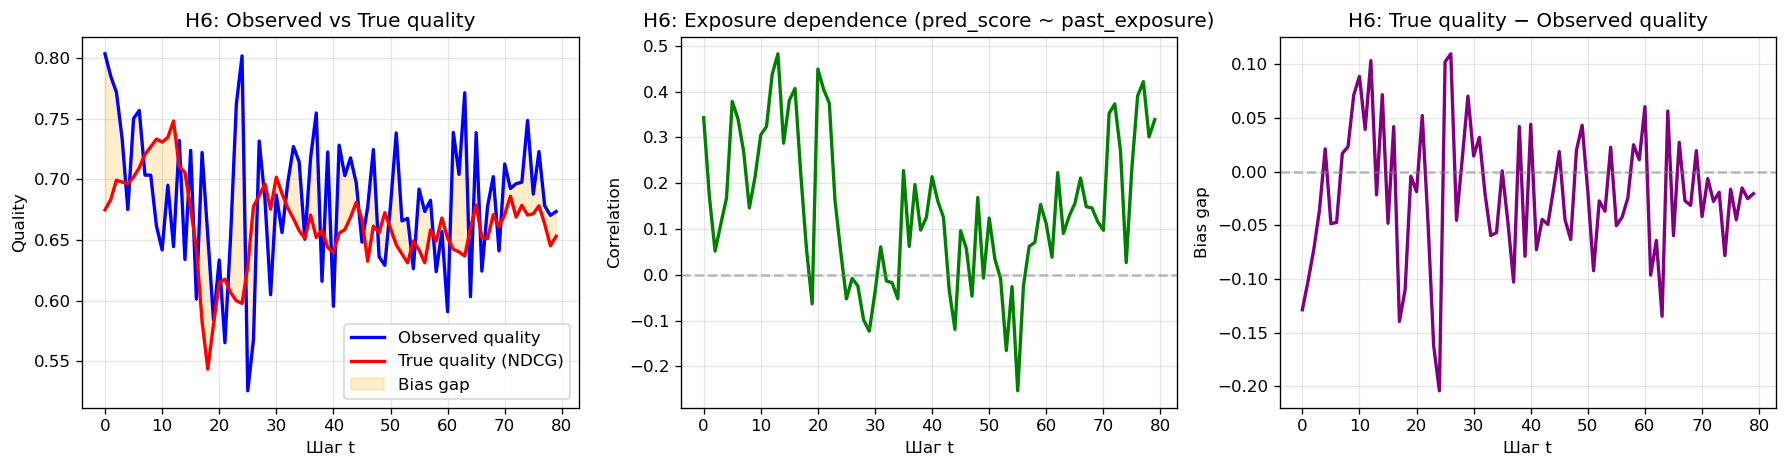

In [4]:
# ── Рисунок 1: Observed vs True quality ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_h6['t'], df_h6['observed_quality'], 'b-', lw=2, label='Observed quality')
axes[0].plot(df_h6['t'], df_h6['true_quality'], 'r-', lw=2, label='True quality (NDCG)')
axes[0].fill_between(df_h6['t'],
 df_h6['true_quality'], df_h6['observed_quality'],
 alpha=0.2, color='orange', label='Bias gap')
axes[0].set_xlabel('Шаг t'); axes[0].set_ylabel('Quality')
axes[0].set_title('H6: Observed vs True quality')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_h6['t'], df_h6['exposure_dependence'], 'g-', lw=2)
axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('Шаг t'); axes[1].set_ylabel('Correlation')
axes[1].set_title('H6: Exposure dependence (pred_score ~ past_exposure)')
axes[1].grid(alpha=0.3)

# Bias gap
bias = df_h6['true_quality'] - df_h6['observed_quality']
axes[2].plot(df_h6['t'], bias, 'purple', lw=2)
axes[2].axhline(0, color='gray', ls='--', alpha=0.5)
axes[2].set_xlabel('Шаг t'); axes[2].set_ylabel('Bias gap')
axes[2].set_title('H6: True quality − Observed quality')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H6_quality_gap.pdf', bbox_inches='tight')
plt.show()

## Deconvolution regression: разложение сигнала обратной связи

**Цель**: разложить наблюдаемые клики на два компонента:
1. Клики из-за истинного качества объекта ($\beta_1 \cdot \text{true\_utility}$).
2. Клики из-за того, что объект часто показывался ($\beta_2 \cdot \text{past\_exposure}$).

**Метод**: линейная регрессия по скользящим временным окнам:
$$\text{click}_{t} = \beta_0 + \beta_1 \cdot p^{\text{true}}_{ij} + \beta_2 \cdot \text{exposure}_{j}^{t} + \varepsilon$$

Если со временем $|\beta_2|$ растёт при снижении $|\beta_1|$ — 
это прямое свидетельство того, что модель «моделирует свою политику, а не мир».

**Техническая реализация**: используем `statsmodels.OLS` (обычный МНК) — 
достаточно для линейного разложения с двумя предикторами.

> **Важное ограничение**: регрессия выявляет корреляцию, а не причинность. 
> Для каузального вывода требуются инструментальные переменные или эксперименты. 
> Тем не менее тренд $\beta_2(t)$ служит надёжным индикатором degradation.

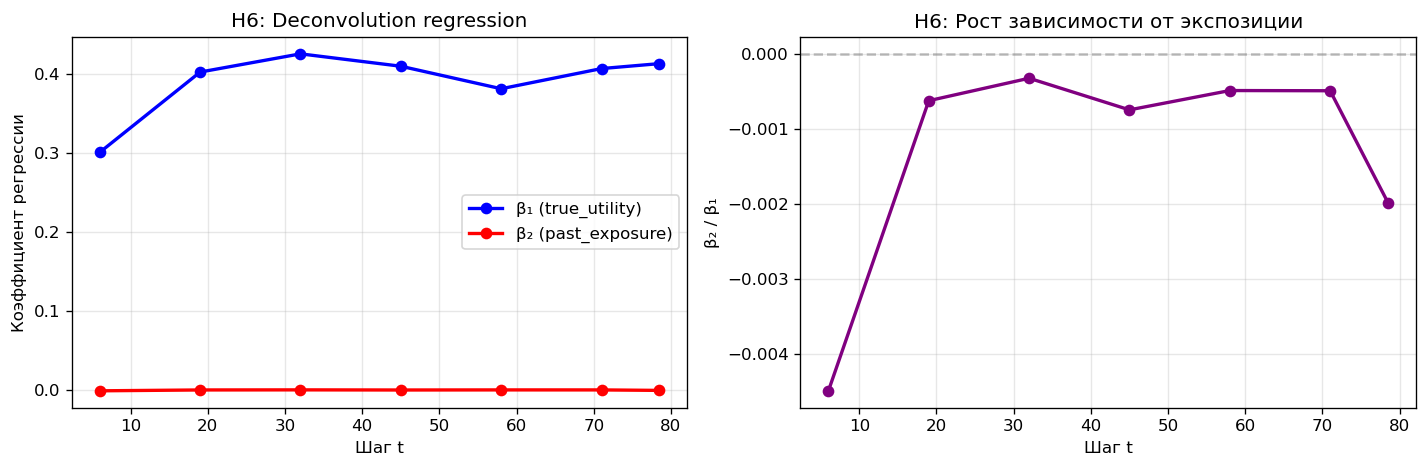


=== H6: β₂/β₁ динамика ===
 t≈6: β₂/β₁ = -0.0045
 t≈19: β₂/β₁ = -0.0006
 t≈32: β₂/β₁ = -0.0003
 t≈45: β₂/β₁ = -0.0007
 t≈58: β₂/β₁ = -0.0005
 t≈71: β₂/β₁ = -0.0005
 t≈78: β₂/β₁ = -0.0020


In [5]:
# ── Deconvolution regression по временным окнам ──────────────────────
if len(logs) > 30:
 window_size = max(len(logs) // 8, 20)
 t_windows = sorted(logs['t'].unique())
 # Группируем по окнам
 step_size = max(1, len(t_windows) // 6)
 windows = [t_windows[i:i+step_size] for i in range(0, len(t_windows), step_size)]

 beta1_list, beta2_list, t_mid_list = [], [], []
 for win in windows:
 sub = logs[logs['t'].isin(win)]
 if len(sub) < 10:
 continue
 X = sm.add_constant(sub[['true_utility', 'past_exposure']].values)
 y = sub['observed_rating'].values
 try:
 res = sm.OLS(y, X).fit()
 beta1_list.append(res.params[1]) # β₁ (true_utility)
 beta2_list.append(res.params[2]) # β₂ (past_exposure)
 t_mid_list.append(float(np.mean(win)))
 except Exception as e:
 print(f'OLS failed for window {win}: {e}')

 if beta1_list:
 ratio = [b2 / (abs(b1) + 1e-9) for b1, b2 in zip(beta1_list, beta2_list)]

 fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 axes[0].plot(t_mid_list, beta1_list, 'b-o', lw=2, label='β₁ (true_utility)')
 axes[0].plot(t_mid_list, beta2_list, 'r-o', lw=2, label='β₂ (past_exposure)')
 axes[0].set_xlabel('Шаг t'); axes[0].set_ylabel('Коэффициент регрессии')
 axes[0].set_title('H6: Deconvolution regression')
 axes[0].legend(); axes[0].grid(alpha=0.3)

 axes[1].plot(t_mid_list, ratio, 'purple', lw=2, marker='o')
 axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
 axes[1].set_xlabel('Шаг t'); axes[1].set_ylabel('β₂ / β₁')
 axes[1].set_title('H6: Рост зависимости от экспозиции')
 axes[1].grid(alpha=0.3)

 plt.tight_layout()
 plt.savefig(FIGURES_DIR / 'H6_deconvolution.pdf', bbox_inches='tight')
 plt.show()

 print('\n=== H6: β₂/β₁ динамика ===')
 for t_m, r in zip(t_mid_list, ratio):
 print(f' t≈{t_m:.0f}: β₂/β₁ = {r:.4f}')
 else:
 print('Недостаточно данных для регрессии')
else:
 print('Недостаточно логов для deconvolution')

In [6]:
# ── Итоговая проверка H6 ─────────────────────────────────────────────
print('=== H6: Проверка гипотезы ===')
ed_trend = np.polyfit(df_h6['t'], df_h6['exposure_dependence'], 1)
print(f' Тренд exposure_dependence: {ed_trend[0]:+.5f}/шаг')

obs_q_start = df_h6['observed_quality'].iloc[:5].mean()
obs_q_end = df_h6['observed_quality'].iloc[-5:].mean()
true_q_start = df_h6['true_quality'].iloc[:5].mean()
true_q_end = df_h6['true_quality'].iloc[-5:].mean()

print(f' observed_quality: {obs_q_start:.3f} -> {obs_q_end:.3f}')
print(f' true_quality: {true_q_start:.3f} -> {true_q_end:.3f}')

if true_q_end < true_q_start:
 print(' True quality деградирует — H6 подтверждена')
else:
 print(' ~ True quality стабильна')

if ed_trend[0] > 0:
 print(' Exposure dependence растёт — H6 подтверждена')
else:
 print(' ~ Exposure dependence убывает')

=== H6: Проверка гипотезы ===
 Тренд exposure_dependence: -0.00091/шаг
 observed_quality: 0.754 -> 0.686
 true_quality: 0.690 -> 0.662
 True quality деградирует — H6 подтверждена
 ~ Exposure dependence убывает
